In [1]:
import pickle
import numpy as np
from matplotlib import pyplot as plt
from tqdm.notebook import tqdm
import csv
from mpl_toolkits.axes_grid1 import host_subplot
from matplotlib import rcParams

from defs import *

%load_ext autoreload
%autoreload 2

In [2]:
# filter out cavities that are too far from the transducer
home_dir = '../../../'
raw_dir = home_dir + 'data/kagome-02.26.2022-center/raw/real_space/'
processed_dir = home_dir + 'data/kagome-02.26.2022-center/preprocessed/real_space/'
sim_raw_dir = home_dir + 'data/kagome-02.26.2022-center-sim/raw/'
sim_processed_dir = home_dir + 'data/kagome-02.26.2022-center-sim/preprocessed/'
out_dir = home_dir + "output/paper_upload/"


# Plot experimental data

In [ ]:
# Pre-process the experimental data

data = pickle.load(open(raw_dir+os.listdir(raw_dir)[0], 'rb'))
frequencies = data[:,0]

preprocess_chirp(data_dir = raw_dir, 
                 frequencies = frequencies, 
                 targetfile = processed_dir, 
                 title = 'scppos_', setno = 0)


Found 164 records
Preprocessing complete!


In [4]:
# Define shared parameters for plotting

preamp_gain = 4.731513 #13.5 dB at minimum gain
mic_gain = 0.02 #0.02V/Pa 

x_unit = 10*np.sqrt(3)/4
y_unit = 7.5
radius = 3.5

## Flat band data

In [ ]:
freq_fb = 14.4
fn = processed_dir + f"_{int(freq_fb*1e3)}.0_0.pkl"
fb_exp_data = pickle.load(open(fn, 'rb'))

max_idx_fb = np.argmax(fb_exp_data[:, 2])
phase_ref_fb = fb_exp_data[max_idx_fb, 3]
value_fb = fb_exp_data[:, 2] /preamp_gain/mic_gain * np.cos(np.deg2rad((fb_exp_data[:, 3] - phase_ref_fb)))
max_amp_flat = np.max(fb_exp_data[:, 2] /preamp_gain/mic_gain)

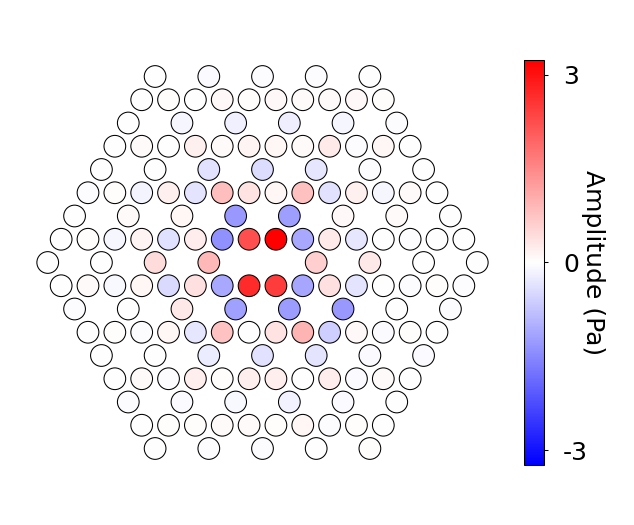

In [ ]:
fig, ax = real_space_plot(
    x_coords=fb_exp_data[:, 0] * x_unit,
    y_coords=fb_exp_data[:, 1] * y_unit,
    value= value_fb,
    max_amp=max_amp_flat,
    radius=radius,
    out_path=out_dir + f"amplitude_plot_{freq_fb}kHz.pdf",
)

## Dispersive band data

In [ ]:
freq_db = 4
fn = processed_dir + f"_{int(freq_db*1e3)}.0_0.pkl"
db_exp_data = pickle.load(open(fn, 'rb'))

max_idx_db = np.argmax(db_exp_data[:, 2])
phase_ref_db = db_exp_data[max_idx_db, 3]
value_db = db_exp_data[:, 2] /preamp_gain/mic_gain * np.cos(np.deg2rad((db_exp_data[:, 3] - phase_ref_db)))

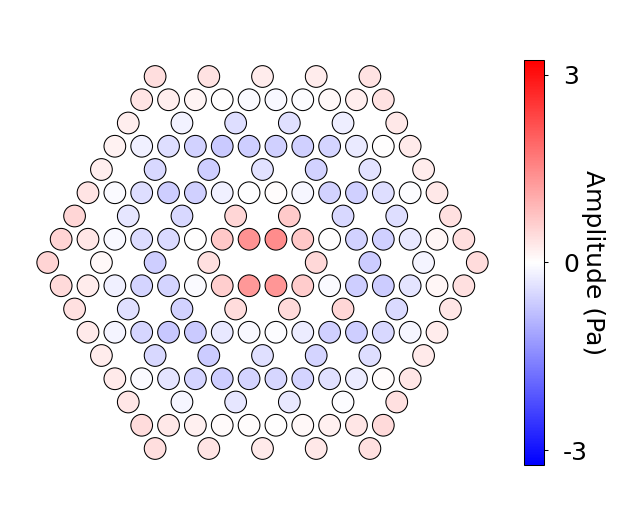

In [ ]:
fig, ax = real_space_plot(
    x_coords=db_exp_data[:, 0] * x_unit,
    y_coords=db_exp_data[:, 1] * y_unit,
    value= value_db,
    max_amp=max_amp_flat,
    radius=radius,
    out_path=out_dir + f"amplitude_plot_{freq_db}kHz.pdf",
)

# Simulation data plotting